# Metrics demo
Calls each function in `metrics.py` on baseline results.

**Baseline data:** no baseline results were provided, so cell 2 generates a synthetic 4-class baseline (a noisy classifier on imbalanced classes). To use your own, replace `y_true` and `y_pred` in that cell with your arrays; everything below works unchanged.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from metrics import confusion_matrix, per_class_accuracy, precision_recall_f1

In [2]:
# ---- Baseline results (REPLACE with real y_true / y_pred) ----
rng = np.random.default_rng(0)
classes = ["cat", "dog", "bird", "fish"]
y_true = rng.choice(classes, size=500, p=[0.4, 0.3, 0.2, 0.1])

# baseline = right 70% of the time, otherwise a random wrong class
y_pred = y_true.copy()
wrong = rng.random(len(y_true)) > 0.70
for i in np.where(wrong)[0]:
    y_pred[i] = rng.choice([c for c in classes if c != y_true[i]])
print(len(y_true), "samples;", "overall accuracy:", round((y_true == y_pred).mean(), 3))

500 samples; overall accuracy: 0.694


## 1. `confusion_matrix()`
Rows = true class, columns = predicted class.

['cat' 'dog' 'bird' 'fish']
[[106  28  22  22]
 [ 11 112  19  11]
 [  7  11  87   6]
 [  7   3   6  42]]


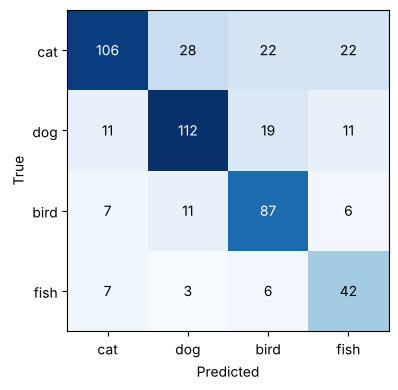

In [3]:
cm, labels = confusion_matrix(y_true, y_pred, labels=classes)
print(labels)
print(cm)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

## 2. `per_class_accuracy()`

In [4]:
acc, labels = per_class_accuracy(y_true, y_pred, labels=classes)
for lab, a in zip(labels, acc):
    print(f"{lab:>5}: {a:.3f}")

  cat: 0.596
  dog: 0.732
 bird: 0.784
 fish: 0.724


## 3. `precision_recall_f1()`

In [5]:
res = precision_recall_f1(y_true, y_pred, labels=classes)
print(f"{'class':>8} {'precision':>9} {'recall':>7} {'f1':>6} {'support':>8}")
for i, lab in enumerate(res['labels']):
    print(f"{lab:>8} {res['precision'][i]:9.3f} {res['recall'][i]:7.3f} {res['f1'][i]:6.3f} {res['support'][i]:8d}")

for avg in ("macro", "weighted", "micro"):
    r = precision_recall_f1(y_true, y_pred, labels=classes, average=avg)
    print(f"{avg:>9}: P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f}")

   class precision  recall     f1  support
     cat     0.809   0.596  0.686      178
     dog     0.727   0.732  0.730      153
    bird     0.649   0.784  0.710      111
    fish     0.519   0.724  0.604       58
    macro: P=0.676 R=0.709 F1=0.683
 weighted: P=0.715 R=0.694 F1=0.695
    micro: P=0.694 R=0.694 F1=0.694


## Sanity check against scikit-learn
Optional; skipped if scikit-learn isn't installed.

In [6]:
try:
    from sklearn.metrics import confusion_matrix as skcm, precision_recall_fscore_support as skprf
    assert (skcm(y_true, y_pred, labels=classes) == cm).all()
    p, r_, f, s = skprf(y_true, y_pred, labels=classes, zero_division=0)
    assert np.allclose(p, res["precision"]) and np.allclose(r_, res["recall"]) and np.allclose(f, res["f1"])
    for avg in ("macro", "weighted", "micro"):
        sp, sr, sf, _ = skprf(y_true, y_pred, labels=classes, average=avg, zero_division=0)
        m = precision_recall_f1(y_true, y_pred, labels=classes, average=avg)
        assert np.allclose([sp, sr, sf], [m["precision"], m["recall"], m["f1"]])
    print("All metrics match scikit-learn.")
except ImportError:
    print("scikit-learn not installed; skipped.")

All metrics match scikit-learn.
